# Step 2 — Deploy (state + image) replay & fixed-point probe

Step 3's probe (deploy_image_probe) showed the output is **dominated by `observation.state`** and
barely uses the image; with a fixed proxy state, deploy and dataset images behaved identically.
So we must replay the **real deploy `(state, image)` pairs**.

- **Part A** needs a fresh deploy run recorded with the **updated `record_obs`** (now logs
  `observation.state` in `metadata.jsonl`). It replays each exact deploy pair and checks whether
  the predicted action ≈ "stay at current state" (= the standstill), then swaps state vs image to
  see which one drives it.
- **Part B** needs only the dataset: a closed-loop **fixed-point probe** from the start pose —
  does the policy command motion away from rest, or echo the current state (fail to initiate)?

Run on the **GPU server**.

In [5]:
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.policies.factory import get_policy_class, make_pre_post_processors

MODEL = "di-techinnova/smolvla-pouring-0.1"
DATASET = "di-techinnova/so-arm-101-pouring-0.2"
RECORDED_DIR = "/home/trietlm/lerobot/recorded_obs"            # a deploy run recorded WITH the updated record_obs
TASK = "Pour from orange cup into blue cup."
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
JOINTS = ["sh_pan", "sh_lift", "elbow", "wr_flex", "wr_roll", "grip"]

policy = get_policy_class("smolvla").from_pretrained(MODEL).to(DEVICE).eval()
pre, post = make_pre_post_processors(
    policy.config,
    pretrained_path=MODEL,
    preprocessor_overrides={
        "device_processor": {"device": DEVICE},
        "rename_observations_processor": {"rename_map": {}},
    },
    postprocessor_overrides={"device_processor": {"device": DEVICE}},
)
IMG_KEYS = [k for k in policy.config.input_features if k.startswith("observation.images.")]

ds = LeRobotDataset(DATASET, video_backend="pyav")  # torchcodec/FFmpeg broken on server
STATE_KEYS = ds.meta.info["features"]["observation.state"]["names"]  # canonical order
try:
    F0 = int(ds.episode_data_index["from"][0]); T0 = int(ds.episode_data_index["to"][0])
except Exception:
    F0, T0 = 0, 450
print("device:", DEVICE, "| state keys:", STATE_KEYS)
print("model image inputs:", IMG_KEYS)

# action for one (state, images) pair -- identical path to the server
def run_action(state, imgs, task=TASK):
    obs = {"observation.state": state.reshape(1, -1).float()}
    for k, im in imgs.items():
        obs[k] = im.unsqueeze(0)
    obs["task"] = task
    policy.reset()
    processed = pre(obs)
    with torch.no_grad():
        chunk = policy.predict_action_chunk(processed)
    if chunk.ndim != 3:
        chunk = chunk.unsqueeze(0)
    return post(chunk[:, 0, :]).detach().cpu().numpy().ravel()[:6]

def imgs_from_dataset(gi):
    item = ds[gi]
    out = {}
    for k in IMG_KEYS:
        if k in item:
            im = item[k]
            if im.dtype == torch.uint8:
                im = im.float() / 255.0
            out[k] = im
    return out

# Deploy used JPEG q90 transport; reproduce it on the raw recorded PNGs.
USE_JPEG = True
JPEG_QUALITY = 90  # matches deploy config image_compress_quality
import cv2
def jpeg_roundtrip(img_chw, quality=JPEG_QUALITY):
    # (3,H,W)[0,1] -> exact server transport: cv2.imencode('.jpg',q) -> cv2.imdecode (same channel order)
    arr = (img_chw.detach().cpu().permute(1, 2, 0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
    ok, enc = cv2.imencode('.jpg', arr, [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return torch.from_numpy(dec).permute(2, 0, 1).float() / 255.0


Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


Loading weights: 100%|██████████| 489/489 [00:00<00:00, 4571.44it/s]


Reducing the number of VLM layers to 16 ...


Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 52374.24it/s]

device: cuda | state keys: ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']
model image inputs: ['observation.images.camera1', 'observation.images.camera2', 'observation.images.camera3']



/tmp/ipykernel_1162771/897356672.py:30: DeprecationWarning: Accessing DatasetInfo with dict-style syntax info['features'] is deprecated. Use attribute access info.features instead.
  STATE_KEYS = ds.meta.info["features"]["observation.state"]["names"]  # canonical order


## Part A — exact deploy (state, image) replay  *(needs a deploy run with state logged)*

In [6]:
meta_path = os.path.join(RECORDED_DIR, "metadata.jsonl")
rows = [json.loads(l) for l in open(meta_path, encoding="utf-8")] if os.path.exists(meta_path) else []
HAS_STATE = bool(rows) and isinstance(rows[0].get("state"), dict) and len(rows[0]["state"]) > 0
print(f"metadata rows: {len(rows)} | state logged: {HAS_STATE}")

def deploy_state(row):
    return torch.tensor([row["state"][k] for k in STATE_KEYS], dtype=torch.float32)

def deploy_imgs(timestep):
    out = {}
    for cam, key in zip(["camera1", "camera2"], ["observation.images.camera1", "observation.images.camera2"]):
        p = os.path.join(RECORDED_DIR, "images", cam, f"{timestep:06d}.png")
        if os.path.exists(p) and key in IMG_KEYS:
            arr = np.asarray(Image.open(p).convert("RGB")).copy()
            im = torch.from_numpy(arr).permute(2, 0, 1).float() / 255.0
            out[key] = jpeg_roundtrip(im) if USE_JPEG else im  # model saw JPEG q90 at deploy
    return out

if HAS_STATE:
    sample = rows[:: max(1, len(rows) // 8)][:8]
    print("\nReplay deploy pairs -> predicted action vs current state (Δ = action - state):")
    A_state, A_pred = [], []
    for row in sample:
        st = deploy_state(row)
        a = run_action(st, deploy_imgs(row["timestep"]))
        A_state.append(st.numpy()); A_pred.append(a)
        d = a - st.numpy()
        print(f"  t={row['timestep']:4d} | state {np.round(st.numpy(),1)} | pred {np.round(a,1)} | Δ {np.round(d,1)}")
    A_state = np.stack(A_state); A_pred = np.stack(A_pred)
    print(f"\nmean |Δ| per joint: {np.round(np.abs(A_pred - A_state).mean(0),1)}")
    print("If Δ ≈ 0 across timesteps -> the policy commands 'stay' = the standstill, reproduced offline.")
else:
    print("\nNo state in metadata. Re-run a short deploy with the updated record_obs, then re-run this cell.")

metadata rows: 49 | state logged: True

Replay deploy pairs -> predicted action vs current state (Δ = action - state):
  t=   0 | state [-5.3 -5.  14.9  2.   2.8  1.1] | pred [-6.5 -7.4 14.   1.2  2.7  1.1] | Δ [-1.2 -2.4 -0.9 -0.8 -0.  -0. ]
  t=  12 | state [-5.3 -1.7  8.5 -1.4  5.   1.1] | pred [-5.2 -5.5  7.7 -0.5  5.2  1.1] | Δ [ 0.1 -3.8 -0.8  0.9  0.2  0. ]
  t=  51 | state [-6.9 -0.7  5.  -1.4  8.6  1.1] | pred [-7.1 -2.4  3.2 -2.   9.1  1.1] | Δ [-0.3 -1.6 -1.9 -0.7  0.6 -0. ]
  t=  90 | state [-6.8  2.7  7.  -3.1  9.7  1.2] | pred [-6.8  1.1  5.5 -2.9  9.4  1. ] | Δ [-0.1 -1.5 -1.6  0.2 -0.3 -0.2]
  t= 129 | state [-6.3 -2.9  9.  -0.5  2.1  1.2] | pred [-6.7 -3.7  6.8 -0.7  2.6  1.2] | Δ [-0.4 -0.9 -2.2 -0.2  0.5  0. ]
  t= 168 | state [-6.9 -1.5  6.5 -0.   1.7  1.2] | pred [-7.6 -3.7  6.1 -0.7  1.5  1.1] | Δ [-0.8 -2.2 -0.5 -0.7 -0.2 -0.1]
  t= 207 | state [-6.1 -2.5  6.9  0.4  2.4  1.2] | pred [-6.  -3.6  6.2  0.   2.6  1.1] | Δ [ 0.  -1.1 -0.8 -0.4  0.1 -0. ]
  t= 246 | st

## Part A — swap test: is it the STATE or the IMAGE?  *(at the deploy start frame)*

In [7]:
if HAS_STATE:
    r0 = rows[0]
    st_dep = deploy_state(r0)
    im_dep = deploy_imgs(r0["timestep"])
    st_ds = ds[F0]["observation.state"]      # dataset start state
    im_ds = imgs_from_dataset(F0)            # dataset start image

    a_base = run_action(st_dep, im_dep)                 # deploy state + deploy image (the real thing)
    a_swap_img = run_action(st_dep, im_ds)              # deploy state + dataset image
    a_swap_state = run_action(st_ds, im_dep)            # dataset state + deploy image
    a_ds = run_action(st_ds, im_ds)                     # both dataset (sanity)
    gt0 = ds[F0]["action"].numpy().ravel()[:6]

    print("deploy state :", np.round(st_dep.numpy(), 1))
    print("dataset state:", np.round(st_ds.numpy(), 1))
    print()
    print("base   (dep state + dep img) :", np.round(a_base, 1))
    print("swapIMG(dep state + ds  img) :", np.round(a_swap_img, 1))
    print("swapST (ds  state + dep img) :", np.round(a_swap_state, 1))
    print("ds     (ds  state + ds  img) :", np.round(a_ds, 1), " | gt:", np.round(gt0, 1))
    print()
    print("If swapST (changing only the STATE) moves the output toward a reach but swapIMG does not,")
    print("=> the STATE is the dominant cause. If swapIMG matters more, the image is.")
else:
    print("Part A swap needs deploy state — skipped.")

deploy state : [-5.3 -5.  14.9  2.   2.8  1.1]
dataset state: [  -4.8 -101.9   97.1   51.    -4.5    1. ]

base   (dep state + dep img) : [ -5.9 -10.   14.4   2.1   2.9   1. ]
swapIMG(dep state + ds  img) : [-5.9 -6.2 17.8  3.   2.4  0.9]
swapST (ds  state + dep img) : [  -6.9 -102.1   94.7   47.6   -2.8    1.2]
ds     (ds  state + ds  img) : [  -6.1 -104.8  100.9   52.3   -5.7    1.1]  | gt: [  -9.  -102.2   96.7   74.2   -7.2    1. ]

If swapST (changing only the STATE) moves the output toward a reach but swapIMG does not,
=> the STATE is the dominant cause. If swapIMG matters more, the image is.


## Part B — closed-loop fixed-point probe (dataset only, no deploy data needed)

From the start pose, feed `(state, start_image)`, take the predicted action as the next state, and
iterate. The image is held at the start frame (a stalled robot sees a near-static scene). If the
state trajectory stays pinned near the start ⇒ the policy **fails to initiate** (a stuck fixed
point) ⇒ that, not the camera, is the standstill mechanism.

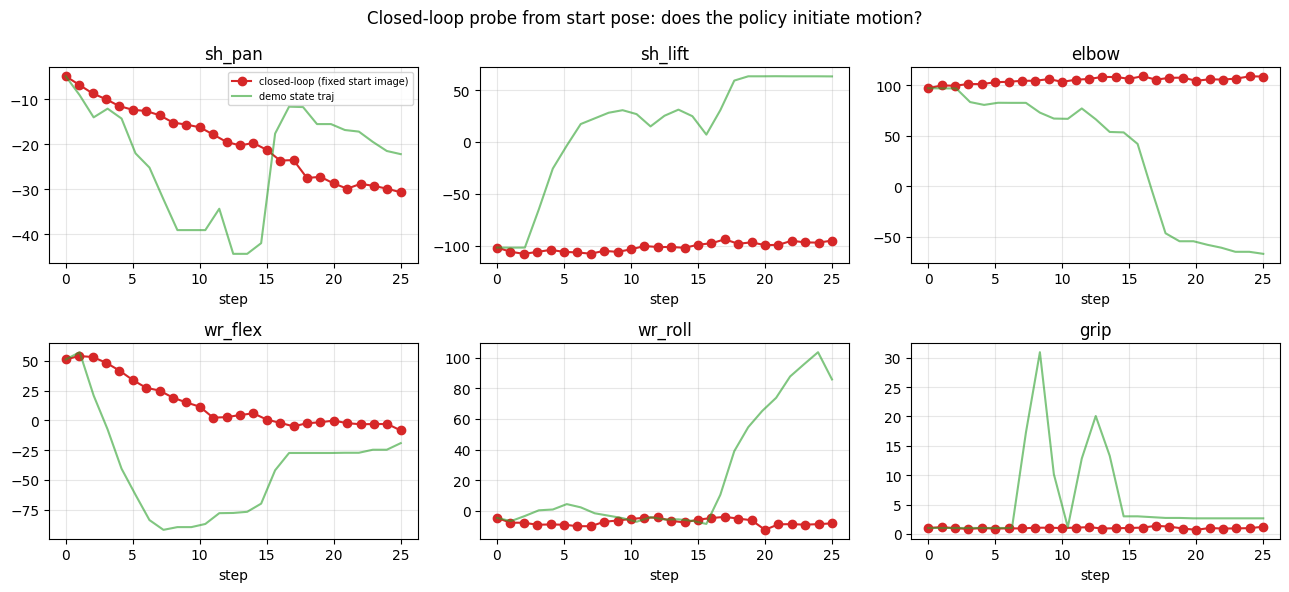

net drift over 25 steps per joint: [25.8  6.8 11.6 59.6  3.6  0.2]
If drift ~ 0 -> stuck fixed point (fails to initiate). If it sweeps toward the demo -> it initiates.


In [8]:
START_GI = F0  # dataset episode-0 start; change to probe other starts
state = ds[START_GI]["observation.state"].clone().float()
img0 = imgs_from_dataset(START_GI)

N = 25
traj = [state.numpy().copy()]
for _ in range(N):
    a = run_action(state, img0)
    state = torch.tensor(a, dtype=torch.float32)
    traj.append(a.copy())
traj = np.stack(traj)

# ground-truth episode trajectory for reference
gt_traj = np.stack([ds[gi]["observation.state"].numpy() for gi in range(F0, min(T0, F0 + 300), 12)])

fig, axs = plt.subplots(2, 3, figsize=(13, 6))
for j, ax in enumerate(axs.ravel()):
    ax.plot(traj[:, j], "o-", color="tab:red", label="closed-loop (fixed start image)")
    ax.plot(np.linspace(0, N, len(gt_traj)), gt_traj[:, j], color="tab:green", alpha=.6, label="demo state traj")
    ax.set_title(JOINTS[j]); ax.set_xlabel("step"); ax.grid(alpha=.3)
    if j == 0:
        ax.legend(fontsize=7)
fig.suptitle("Closed-loop probe from start pose: does the policy initiate motion?")
plt.tight_layout(); plt.show()

drift = np.abs(traj[-1] - traj[0])
print("net drift over", N, "steps per joint:", np.round(drift, 1))
print("If drift ~ 0 -> stuck fixed point (fails to initiate). If it sweeps toward the demo -> it initiates.")

## How to read

- **Part A — Δ ≈ 0 on real deploy pairs** → the policy literally commands "stay" at the deploy
  state = the standstill, reproduced deterministically. The **swap test** then says whether the
  STATE or the IMAGE is responsible.
- **Part B — red curve stays flat near the start** → the policy can't initiate from rest (a stuck
  fixed point); the standstill is intrinsic to the policy at the start pose, not a sensor issue.
  **Red curve sweeps toward the green demo** → it does initiate, so the closed-loop failure is
  elsewhere (e.g. RTC aggregation / control loop).